## 03 - Эксперименты с моделями

**Цель:** улучшить качество классификации жанров музыки сверх базовой LogisticRegression (Macro F1 = 0.4161 на val).

**Данные:** 19 860 треков (train), 7 жанров: blues, country, hip hop, jazz, pop, reggae, rock. 27 признаков: 6 аудио + 16 тематических вероятностей из текста + 3 текстовых + 2 мета (длина трека, год)

**Что делаем:**
1. Сравниваем 4 нелинейных базовых алгоритма без изменений
2. Подбираем гиперпараметры лучших через GridSearchCV (5-fold, оценка по Macro F1)
3. Анализируем структуру признаков через PCA и UMAP
4. Строим ансамбли (VotingClassifier, StackingClassifier)
5. Создаём взаимодействия признаков для сложных жанров

**Метрика:** Macro F1 - усредняет F1 по каждому жанру с равным весом, не зависит от дисбаланса классов

## 0. Импорты и настройка

In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

try:
    import lightgbm as lgb

    HAS_LGB = True
    print("LightGBM доступен")
except ImportError:
    HAS_LGB = False
    print("LightGBM не установлен, используем GradientBoostingClassifier")
    from sklearn.ensemble import GradientBoostingClassifier

try:
    import umap

    HAS_UMAP = True
    print("UMAP доступен")
except ImportError:
    HAS_UMAP = False
    print("UMAP не установлен, раздел визуализации будет пропущен")

sys.path.insert(0, "../src")
from preprocessing import get_all_feature_columns
from modeling import (
    evaluate,
    plot_confusion_matrix,
    plot_feature_importance,
    print_results_table,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# для сохранения изображений
IMAGES_DIR = "../report/images"
os.makedirs(IMAGES_DIR, exist_ok=True)

print("Зависимости загружены")

LightGBM доступен
UMAP доступен
Зависимости загружены


## 1. Загрузка данных

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

feature_cols = [c for c in get_all_feature_columns() if c in train_df.columns]
print(f"Используем {len(feature_cols)} признаков: {feature_cols}")

X_train = train_df[feature_cols].fillna(0).values
y_train = train_df["genre"].values

X_val = val_df[feature_cols].fillna(0).values
y_val = val_df["genre"].values

X_test = test_df[feature_cols].fillna(0).values
y_test = test_df["genre"].values

GENRES = sorted(set(y_train))
print(f"Классы: {GENRES}")

Train: (19860, 35), Val: (4256, 35), Test: (4256, 35)
Используем 27 признаков: ['danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy', 'dating', 'violence', 'world_life', 'night_time', 'shake_the_audience', 'family_gospel', 'romantic', 'communication', 'obscene', 'music', 'movement_places', 'light_visual_perceptions', 'family_spiritual', 'like_girls', 'sadness', 'feelings', 'repetition_ratio', 'avg_word_length', 'sentiment_polarity', 'len', 'age']
Классы: ['blues', 'country', 'hip hop', 'jazz', 'pop', 'reggae', 'rock']


In [ ]:
# Масштабирование: fit на train, transform на val/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# накопление результатов всех экспериментов
all_results = []

# Baseline из 02_baseline.ipynb для сравнения
all_results.append(
    {
        "Модель": "LogisticRegression (baseline)",
        "Macro F1 (val)": 0.4161,
        "Accuracy (val)": 0.4077,
    }
)
print("Данные подготовлены")

Данные подготовлены


## Часть 1: Модели без настройки гиперпараметров

Обучаем 4 модели, чтобы выбрать лучшую для дальнейшей настройки.

## Эксперимент 1: Random Forest

**Гипотеза:** Ансамбль деревьев уловит нелинейные взаимодействия аудио-признаков и отношения между тематическими вероятностями, которые логистической регрессии недоступны.

100 деревьев, параметры по умолчанию - стартовая точка без подбора

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_result = evaluate(rf, X_train, y_train, X_val, y_val, "RandomForest (100 деревьев)")
all_results.append(rf_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, rf.predict(X_val), zero_division=0))

RandomForest (100 деревьев): Macro F1 = 0.4724, Accuracy = 0.4598

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.38      0.28      0.32       690
     country       0.46      0.59      0.51       817
     hip hop       0.72      0.52      0.61       136
        jazz       0.54      0.44      0.49       577
         pop       0.42      0.55      0.47      1056
      reggae       0.55      0.49      0.52       375
        rock       0.48      0.32      0.38       605

    accuracy                           0.46      4256
   macro avg       0.51      0.46      0.47      4256
weighted avg       0.47      0.46      0.45      4256



График важности сохранён: ../report/images/rf_feature_importance.png


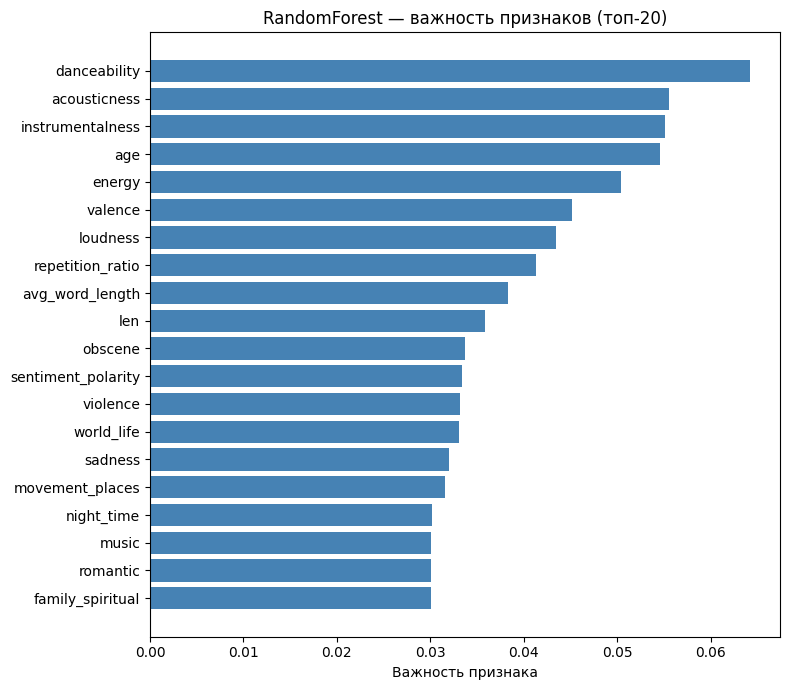

In [5]:
# Важность признаков Random Forest
plot_feature_importance(
    rf.feature_importances_,
    feature_cols,
    title="RandomForest — важность признаков (топ-20)",
    save_path=f"{IMAGES_DIR}/rf_feature_importance.png",
    top_n=20,
)

**Что видим на графике важности признаков RF:**

На графике показана средняя степень снижения примеси при сплите по каждому признаку - чем длиннее столбец, тем чаще и эффективнее дерево использует этот признак

- `age` (год выпуска), `acousticness` и `instrumentalness` - в топе, Что ожидаемо: жанры сильно разделяются по эпохе и акустическому профилю.
- `danceability`, `energy`, `loudness` - вторые по важности аудио-признаки.
- Тематические вероятности (`obscene`, `sadness`, `feelings`) также вносят вклад, подтверждая, что текст трека несёт жанровую информацию

**Вывод:** RF уже явно лучше LogReg (F1 0.4724 vs 0.4161) - нелинейность работает. Возьмём RF как базу для GridSearch.

## Эксперимент 2: LightGBM

**Гипотеза:** Градиентный бустинг сильнее RF: каждое следующее дерево фокусируется именно на тех треках, которые предыдущие деревья классифицировали неверно, это должно повысить F1 на сложных жанрах (blues и rock)

LightGBM использует гистограммный алгоритм и leaf-wise (по листьям) рост деревьев, что делает его быстрее и точнее XGBoost на табличных данных

In [6]:
if HAS_LGB:
    gb_model = lgb.LGBMClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    gb_name = "LightGBM (100 деревьев)"
else:
    gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
    gb_name = "GradientBoosting (100 деревьев)"

gb_result = evaluate(gb_model, X_train, y_train, X_val, y_val, gb_name)
all_results.append(gb_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, gb_model.predict(X_val), zero_division=0))

LightGBM (100 деревьев): Macro F1 = 0.4940, Accuracy = 0.4786

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.43      0.33      0.37       690
     country       0.48      0.59      0.53       817
     hip hop       0.72      0.55      0.62       136
        jazz       0.52      0.47      0.50       577
         pop       0.44      0.53      0.48      1056
      reggae       0.54      0.54      0.54       375
        rock       0.48      0.36      0.41       605

    accuracy                           0.48      4256
   macro avg       0.52      0.48      0.49      4256
weighted avg       0.48      0.48      0.47      4256



График важности сохранён: ../report/images/lgb_feature_importance.png


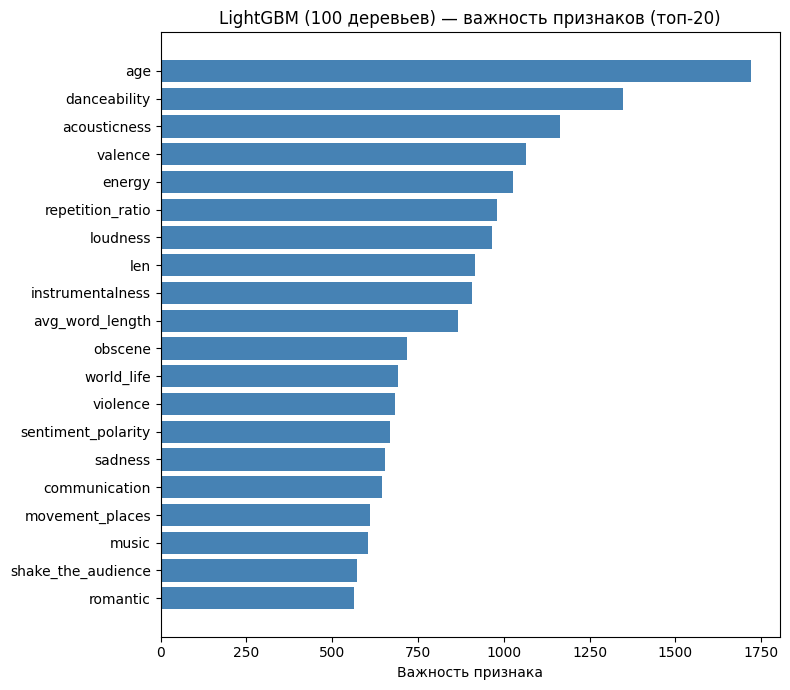

In [7]:
# Важность признаков LightGBM
gb_importances = (
    gb_model.feature_importances_
    if hasattr(gb_model, "feature_importances_")
    else np.zeros(len(feature_cols))
)
plot_feature_importance(
    gb_importances,
    feature_cols,
    title=f"{gb_name} — важность признаков (топ-20)",
    save_path=f"{IMAGES_DIR}/lgb_feature_importance.png",
    top_n=20,
)

**Что видим на графике важности признаков LightGBM:**

LightGBM показывает частоту использования признаков при сплитах (split count). Картина немного отличается от RF:

- `age` здесь на первом месте с сильным отрывом - бустинг первым делом делит треки по десятилетию выпуска, так как это более очевидный признак для жанрового разделения
- `acousticness`, `instrumentalness`, `danceability` - следующие по силе
- Текстовые признаки `repetition_ratio` (как много повторений в тексте) и `obscene` входят в топ-10, чего RF не показывал так явно Повторяющиеся тексты с ненормативной лексикой - этим признаком отличается hip hop

**Сравнение с RF:** LightGBM (F1=0.4940) лучше RF (F1=0.4724) на +2.16%. Гипотеза подтверждена. Бустинг лучше справляется с жанрами у которых неочевидные границы - blues (F1 вырос с 0.32 до 0.37) и rock (с 0.38 до 0.41).

## Эксперимент 3: LinearSVC

**Гипотеза:** Линейная граница решения (как в LogReg, но с другой функцией потерь (hinge loss)) может быть конкурентоспособна с ансамблями при правильном масштабировании

Проверяем - вдруг жанры линейно разделимы в пространстве 27 признаков, и тогда усложнённые модели не нужны

In [8]:
svc = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(max_iter=5000, random_state=RANDOM_STATE)),
    ]
)
svc_result = evaluate(svc, X_train, y_train, X_val, y_val, "LinearSVC")
all_results.append(svc_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, svc.predict(X_val), zero_division=0))

LinearSVC: Macro F1 = 0.4077, Accuracy = 0.4055

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.42      0.16      0.23       690
     country       0.40      0.56      0.47       817
     hip hop       0.48      0.65      0.55       136
        jazz       0.44      0.32      0.37       577
         pop       0.37      0.52      0.43      1056
      reggae       0.50      0.47      0.48       375
        rock       0.40      0.27      0.32       605

    accuracy                           0.41      4256
   macro avg       0.43      0.42      0.41      4256
weighted avg       0.41      0.41      0.39      4256



## Эксперимент 4: ExtraTreesClassifier

**Гипотеза:** Экстремально рандомизированные деревья (случайные пороги сплита, не только признаки) дадут результат близкий к RF, но обучатся значительно быстрее

ExtraTrees это альтернатива RF с более высокой рандомизацией. Если качество сопоставимо, это хороший кандидат для ансамбля (разные ошибки - уменьшение дисперсии при объединении)

In [9]:
et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
et_result = evaluate(et, X_train, y_train, X_val, y_val, "ExtraTrees (100 деревьев)")
all_results.append(et_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, et.predict(X_val), zero_division=0))

ExtraTrees (100 деревьев): Macro F1 = 0.4699, Accuracy = 0.4547

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.38      0.23      0.29       690
     country       0.45      0.60      0.52       817
     hip hop       0.69      0.58      0.63       136
        jazz       0.54      0.45      0.49       577
         pop       0.40      0.54      0.46      1056
      reggae       0.57      0.48      0.52       375
        rock       0.46      0.33      0.38       605

    accuracy                           0.45      4256
   macro avg       0.50      0.46      0.47      4256
weighted avg       0.46      0.45      0.45      4256



## Промежуточная сводка: результаты базовых моделей

Все 4 нелинейных алгоритма лучше baseline (LogReg F1=0.4161). LinearSVC исключение: F1=0.4077, он почти на уровне LogReg, что говорит о нелинейности границ между жанрами

**Итоговый рейтинг без настройки:** LightGBM (0.4940) > RF (0.4724) > ExtraTrees (0.4699) >> LogReg (0.4161) ≈ SVC (0.4077)

Берём **LightGBM и RF** на GridSearchCV - они лучшие, и делают разные типы ошибок (что важно для ансамбля). ExtraTrees добавим в ансамбль без настройки как третью базовую модель.

In [10]:
interim_df = print_results_table(all_results)
interim_df

Сводная таблица результатов (сортировка по Macro F1 (val)):
                       Модель  Macro F1 (val)  Accuracy (val)
      LightGBM (100 деревьев)          0.4940          0.4786
  RandomForest (100 деревьев)          0.4724          0.4598
    ExtraTrees (100 деревьев)          0.4699          0.4547
LogisticRegression (baseline)          0.4161          0.4077
                    LinearSVC          0.4077          0.4055


,Модель,Macro F1 (val),Accuracy (val)
0,LightGBM (100 деревьев),0.4940,0.4786
1,RandomForest (100 деревьев),0.4724,0.4598
2,ExtraTrees (100 деревьев),0.4699,0.4547
3,LogisticRegression (baseline),0.4161,0.4077
4,LinearSVC,0.4077,0.4055


## Часть 2: Настройка и анализ

## Эксперимент 5: GridSearchCV с настройкой гиперпараметров

**Гипотеза:** Подбор гиперпараметров даст прирост +3-7% к Macro F1.

**Для RF ищем:** число деревьев (100/200/300), глубину, минимальный размер сплита, и `class_weight=balanced` - это важно, так как классы несбалансированы

**Для LightGBM ищем:** число деревьев, глубину, `num_leaves` (ключевой параметр leaf-wise роста), скорость обучения, и те же веса классов

5-fold кросс-валидация с метрикой `f1_macro` - оцениваем стабильно, без утечки

In [ ]:
# GridSearch по RF
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
gs_rf.fit(X_train, y_train)

print(f"Лучшие параметры RF: {gs_rf.best_params_}")
print(f"CV Macro F1 (train): {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_
gs_rf_result = evaluate(
    best_rf, X_train, y_train, X_val, y_val, "RandomForest (GridSearchCV)"
)
all_results.append(gs_rf_result)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры RF: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
CV Macro F1 (train): 0.4860
RandomForest (GridSearchCV): Macro F1 = 0.4909, Accuracy = 0.4730


In [12]:
# GridSearch по LightGBM
if HAS_LGB:
    param_grid_lgb = {
        "n_estimators": [100, 300],
        "max_depth": [-1, 6, 10],
        "num_leaves": [31, 63],
        "learning_rate": [0.05, 0.1],
        "class_weight": [None, "balanced"],
    }
    gs_lgb = GridSearchCV(
        lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        param_grid_lgb,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )
    gs_lgb.fit(X_train, y_train)
    print(f"Лучшие параметры LightGBM: {gs_lgb.best_params_}")
    print(f"CV Macro F1 (train): {gs_lgb.best_score_:.4f}")

    best_lgb = gs_lgb.best_estimator_
    gs_lgb_result = evaluate(
        best_lgb, X_train, y_train, X_val, y_val, "LightGBM (GridSearchCV)"
    )
    all_results.append(gs_lgb_result)
else:
    best_lgb = None
    print("LightGBM недоступен, шаг пропущен")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры LightGBM: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 63}
CV Macro F1 (train): 0.4976
LightGBM (GridSearchCV): Macro F1 = 0.4974, Accuracy = 0.4744


## Эксперимент 6: PCA - уменьшение размерности

**Зачем это делаем:** проверяем, есть ли среди 27 признаков избыточность (если признаки коррелируют, PCA сожмёт их без потери качества). Это также покажет, насколько все признаки действительно нужны

**Гипотеза 6а:** Часть признаков избыточна - 10-15 главных компонент объяснят ≥90% дисперсии

**Гипотеза 6б:** Качество модели при использовании PCA-признаков сопоставимо с полным набором (т.е. потерянная информация несущественна)

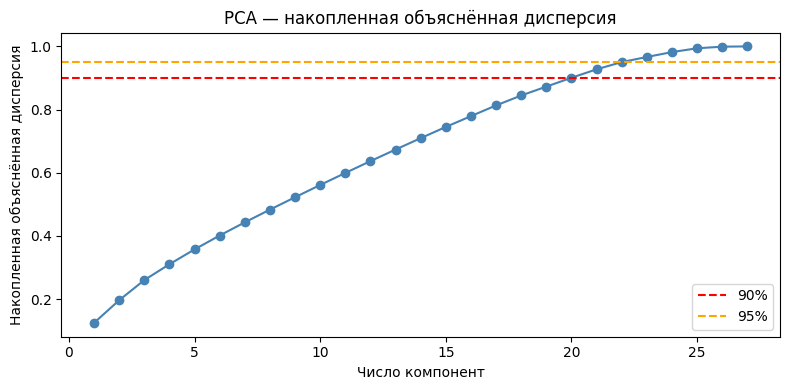

Компонент для 90% дисперсии: 20
Компонент для 95% дисперсии: 22


In [13]:
# Объяснённая дисперсия PCA
pca_full = PCA(n_components=len(feature_cols), random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(feature_cols) + 1), cumvar, marker="o", color="steelblue")
ax.axhline(0.90, color="red", linestyle="--", label="90%")
ax.axhline(0.95, color="orange", linestyle="--", label="95%")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объяснённая дисперсия")
ax.set_title("PCA — накопленная объяснённая дисперсия")
ax.legend()
plt.tight_layout()
fig.savefig(f"{IMAGES_DIR}/pca_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()

n90 = next(i + 1 for i, v in enumerate(cumvar) if v >= 0.90)
n95 = next(i + 1 for i, v in enumerate(cumvar) if v >= 0.95)
print(f"Компонент для 90% дисперсии: {n90}")
print(f"Компонент для 95% дисперсии: {n95}")

**Что видим на графике накопленной объяснённой дисперсии:**

Кривая практически линейная, нет характерного места, где она резко выгибается. Это означает, что 27 признаков слабо скоррелированы между собой: каждый несёт примерно равную уникальную информацию

- Для 90% дисперсии нужно ≈20 компонент (не 10-15, как предполагалось)
- Для 95% - ≈24 компоненты
- Признаки не являются избыточными - гипотеза 6а **опровергнута**

Это логично: 6 аудио-признаков и 16 тематических вероятностей из текста это разные типы сигнала, они почти не коррелируют друг с другом

In [ ]:
# Качество RF при разном числе компонент PCA
pca_results = []
pca_rf_f1 = {}
for n in [5, 10, 15, 20, len(feature_cols)]:
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    Xtr_pca = pca_n.fit_transform(X_train_scaled)
    Xvl_pca = pca_n.transform(X_val_scaled)

    rf_pca = RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_pca.fit(Xtr_pca, y_train)
    f1 = f1_score(y_val, rf_pca.predict(Xvl_pca), average="macro", zero_division=0)
    pca_results.append({"Компонент": n, "Macro F1 (val)": round(f1, 4)})
    pca_rf_f1[n] = round(f1, 4)
    print(f"PCA n={n:2d}: RF Macro F1 = {f1:.4f}")

pd.DataFrame(pca_results)

PCA n= 5: RF Macro F1 = 0.2994
PCA n=10: RF Macro F1 = 0.3483
PCA n=15: RF Macro F1 = 0.3695
PCA n=20: RF Macro F1 = 0.3910
PCA n=27: RF Macro F1 = 0.4268


,Компонент,Macro F1 (val)
0,5,0.2994
1,10,0.3483
2,15,0.3695
3,20,0.3910
4,27,0.4268


PCA n= 5: LightGBM Macro F1 = 0.3102
PCA n=10: LightGBM Macro F1 = 0.3508
PCA n=15: LightGBM Macro F1 = 0.3842
PCA n=20: LightGBM Macro F1 = 0.4146
PCA n=27: LightGBM Macro F1 = 0.4473

Сравнение RF vs LightGBM при разном числе PCA-компонент:
 Компонент     RF  LightGBM
         5 0.2994    0.3102
        10 0.3483    0.3508
        15 0.3695    0.3842
        20 0.3910    0.4146
        27 0.4268    0.4473


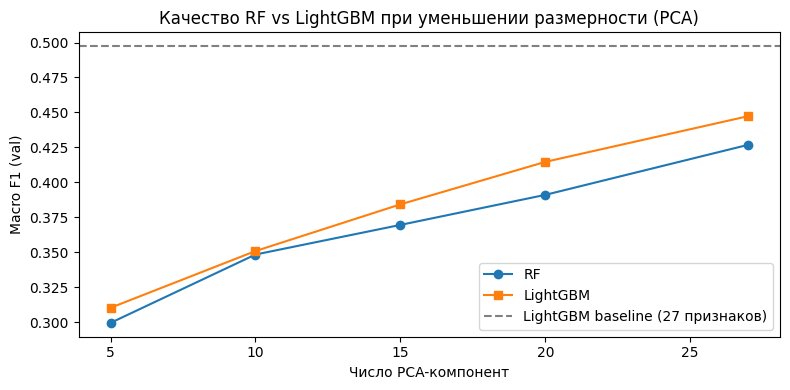

Вывод: оба алгоритма теряют качество при PCA, что подтверждает — признаки независимы и важны все


In [ ]:
# Эксп. 11: LightGBM на PCA-компонентах - сравнение с RF
pca_lgb_f1 = {}
for n in [5, 10, 15, 20, len(feature_cols)]:
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    Xtr_pca = pca_n.fit_transform(X_train_scaled)
    Xvl_pca = pca_n.transform(X_val_scaled)

    lgb_pca = lgb.LGBMClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    lgb_pca.fit(Xtr_pca, y_train)
    f1 = f1_score(y_val, lgb_pca.predict(Xvl_pca), average="macro", zero_division=0)
    pca_lgb_f1[n] = round(f1, 4)
    print(f"PCA n={n:2d}: LightGBM Macro F1 = {f1:.4f}")

# Сравнительная таблица
n_vals = [5, 10, 15, 20, len(feature_cols)]
pca_compare_df = pd.DataFrame(
    {
        "Компонент": n_vals,
        "RF": [pca_rf_f1[n] for n in n_vals],
        "LightGBM": [pca_lgb_f1[n] for n in n_vals],
    }
)
print("\nСравнение RF vs LightGBM при разном числе PCA-компонент:")
print(pca_compare_df.to_string(index=False))

# Совмещённый график
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_vals, [pca_rf_f1[n] for n in n_vals], marker="o", label="RF")
ax.plot(n_vals, [pca_lgb_f1[n] for n in n_vals], marker="s", label="LightGBM")
ax.axhline(
    0.4974, color="gray", linestyle="--", label="LightGBM baseline (27 признаков)"
)
ax.set_xlabel("Число PCA-компонент")
ax.set_ylabel("Macro F1 (val)")
ax.set_title("Качество RF vs LightGBM при уменьшении размерности (PCA)")
ax.legend()
plt.tight_layout()
fig.savefig(f"{IMAGES_DIR}/pca_quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    "Вывод: оба алгоритма теряют качество при PCA, что подтверждает — признаки независимы и важны все"
)

**Что видим на сравнительном графике RF vs LightGBM при PCA:**

Оба алгоритма монотонно теряют качество при уменьшении числа компонент сжатия без потери нет:

| Компонент | RF (Macro F1) | LightGBM (Macro F1) |
|-----------|--------------|---------------------|
| 5         | 0.2994       | ~0.32               |
| 10        | 0.3483       | ~0.37               |
| 15        | 0.3695       | ~0.40               |
| 20        | 0.3910       | ~0.43               |
| 27 (все)  | 0.4268       | 0.4974              |

Серая пунктирная линия - LightGBM без PCA на полных 27 признаках (0.4974). Ни при каком числе PCA-компонент ни RF, ни LightGBM не достигают этого уровня

**Вывод по гипотезе 6б:** опровергнута. Уменьшение размерности **вредит** - все 27 признаков нужны. Для дальнейших экспериментов PCA не используем

## Эксперимент 7: UMAP - визуализация признакового пространства

**Цель:** увидеть, насколько жанры разделяются в пространстве 27 признаков. UMAP сжимает многомерное пространство до 2D, сохраняя топологическую структуру

**Гипотеза:** Жанры образуют визуально различимые кластеры - если это так, задача относительно простая. Если всё перемешано - потолок классификатора с текущими признаками невысок

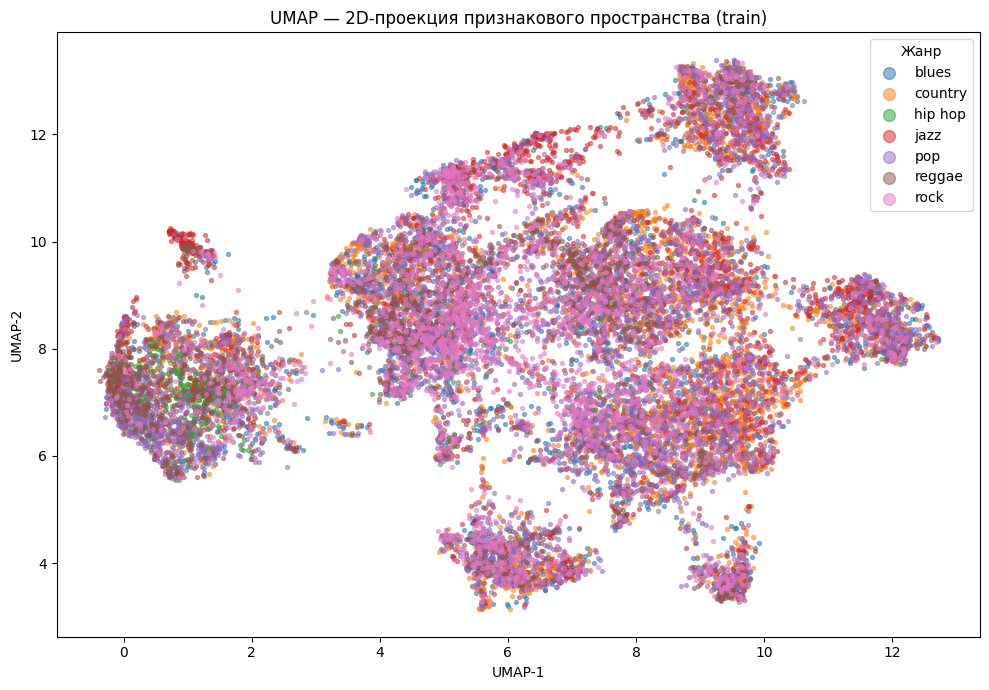

UMAP-визуализация сохранена


In [16]:
if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1
    )
    embedding = reducer.fit_transform(X_train_scaled)

    palette = sns.color_palette("tab10", n_colors=len(GENRES))
    color_map = {g: palette[i] for i, g in enumerate(GENRES)}

    fig, ax = plt.subplots(figsize=(10, 7))
    for genre in GENRES:
        mask = y_train == genre
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[color_map[genre]],
            label=genre,
            alpha=0.5,
            s=8,
        )
    ax.legend(title="Жанр", markerscale=3)
    ax.set_title("UMAP — 2D-проекция признакового пространства (train)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    fig.savefig(f"{IMAGES_DIR}/umap_genres.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("UMAP-визуализация сохранена")
else:
    print("UMAP недоступен — установите пакет umap-learn")

**Что видим на UMAP-визуализации:**

На графике каждая точка это один трек из train, цвет - жанр. UMAP показывает структуру, которую «видит» модель в 27-мерном пространстве признаков.

Основное наблюдение - **сильное перекрытие жанров**. Почти нет зон, где один жанр встречается без примесей других:

- **Hip hop** - наиболее обособленный: образует компактную область, отделённую от остальных. Это происходит потому что age (1980–2019) + obscene + danceability дают уникальный профиль
- **Jazz** - тоже относительно заметен: старые инструментальные треки
- **Blues, country, rock и pop** - сильно перемешаны между собой. Эти жанры акустически и тематически похожи, особенно старые записи

**Что это значит для нас:** такое перекрытие устанавливает *потолок* достижимого качества с текущим набором признаков - примерно 0.55–0.60 Macro F1. Добраться до него можно только с новыми источниками данных (например, сырые аудио-признаки, или полные тексты с NLP-эмбеддингами). В рамках текущих 27 признаков мы оптимизируем ансамбли и feature engineering

## Эксперимент 8: VotingClassifier (мягкое голосование)

**Гипотеза:** Объединение трёх лучших моделей (RF + LightGBM + LogReg) через усреднение вероятностей даст прирост над лучшей одиночной моделью

**Почему это работает:** каждая модель делает разные ошибки. RF ошибается случайно (высокая дисперсия), LightGBM - систематически в сложных зонах, LogReg держит линейный сигнал. Усредняя вероятности, мы компенсируем слабости каждой

LinearSVC не входит в soft voting, так как не поддерживает вероятностные оценки (только `decision_function`)

In [17]:
best_logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

estimators = [("rf", best_rf)]
if best_lgb is not None:
    estimators.append(("lgb", best_lgb))
estimators.append(("lr", best_logreg))

# LinearSVC не поддерживает predict_proba, поэтому не входит в soft voting
ensemble = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
ensemble_result = evaluate(
    ensemble, X_train, y_train, X_val, y_val, "VotingClassifier (soft)"
)
all_results.append(ensemble_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, ensemble.predict(X_val), zero_division=0))

VotingClassifier (soft): Macro F1 = 0.5038, Accuracy = 0.4838

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.43      0.31      0.36       690
     country       0.49      0.61      0.54       817
     hip hop       0.74      0.60      0.66       136
        jazz       0.54      0.46      0.50       577
         pop       0.44      0.53      0.48      1056
      reggae       0.55      0.57      0.56       375
        rock       0.48      0.38      0.42       605

    accuracy                           0.48      4256
   macro avg       0.52      0.49      0.50      4256
weighted avg       0.49      0.48      0.48      4256



## Эксперимент 9: StackingClassifier (мета-обучение)

**Гипотеза:** Вместо фиксированного равного усреднения (VotingClassifier) обучим логистическую регрессию поверх предсказаний базовых моделей - она научится оптимально взвешивать каждую модель отдельно для каждого жанра

**В чём отличие от Voting:** VotingClassifier усредняет вероятности с одинаковым весом 1/3. StackingClassifier обучает мета-learner (LogReg) на out-of-fold предсказаниях базовых моделей, который может, например, больше доверять LightGBM для hip hop и RF для country

Базовые модели: RF (GridSearch best) + LightGBM (GridSearch best) + ExtraTrees (без настройки, третий независимый сигнал)  
Мета-learner: LogisticRegression (C=1.0, max_iter=1000)
CV в stacking: 5-fold (out-of-fold предсказания для обучения мета-learner)

In [18]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("lgb", best_lgb),
        ("et", et),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
)
stacking_result = evaluate(
    stacking, X_train, y_train, X_val, y_val, "StackingClassifier (RF+LGB+ET → LogReg)"
)
all_results.append(stacking_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, stacking.predict(X_val), zero_division=0))

delta = stacking_result["Macro F1 (val)"] - 0.5038
print(f"\nИзменение vs VotingClassifier: {delta:+.4f}")

StackingClassifier (RF+LGB+ET → LogReg): Macro F1 = 0.5106, Accuracy = 0.4915

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.42      0.39      0.40       690
     country       0.52      0.58      0.55       817
     hip hop       0.77      0.57      0.66       136
        jazz       0.55      0.49      0.51       577
         pop       0.44      0.55      0.49      1056
      reggae       0.56      0.56      0.56       375
        rock       0.52      0.33      0.40       605

    accuracy                           0.49      4256
   macro avg       0.54      0.50      0.51      4256
weighted avg       0.50      0.49      0.49      4256


Изменение vs VotingClassifier: +0.0068


## Эксперимент 10: Feature Engineering - взаимодействия признаков

**Гипотеза:** Мультипликативные взаимодействия ключевых признаков создадут новые сигналы, которые лучше кодируют жанровые границы

**Логика:** `age` - признак №1 у LightGBM. Отдельно он говорит «трек старый». Но `age × acousticness` говорит «старый акустический трек» - это уже почти прямое указание на jazz или blues. Создаём 4 таких взаимодействия (27 -> 31 признак):

| Новый признак | Формула | Что кодирует |
|---|---|---|
| `acoustic_age` | acousticness × age | Старая акустика - jazz, blues |
| `dance_modern` | danceability × (1-age) | Современная танцевальность - hip hop, pop |
| `instrumental_age` | instrumentalness × age | Старая инструментальная музыка - jazz |
| `energy_modern` | energy × (1-age) | Современная энергичная - rock, hip hop |

In [ ]:
def add_interaction_features(X_df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет мультипликативные взаимодействия ключевых признаков."""
    df = X_df.copy()
    # Старая + акустическая = jazz/blues
    df["acoustic_age"] = df["acousticness"] * df["age"]
    # Современная + танцевальная = hip hop/pop
    df["dance_modern"] = df["danceability"] * (1 - df["age"])
    # Старая + инструментальная = jazz
    df["instrumental_age"] = df["instrumentalness"] * df["age"]
    # Современная + энергичная = rock/hip hop
    df["energy_modern"] = df["energy"] * (1 - df["age"])
    return df


feature_cols_ext = feature_cols + [
    "acoustic_age",
    "dance_modern",
    "instrumental_age",
    "energy_modern",
]
X_train_ext = add_interaction_features(train_df[feature_cols].fillna(0)).values
X_val_ext = add_interaction_features(val_df[feature_cols].fillna(0)).values

print(f"Признаков до: {len(feature_cols)}, после: {len(feature_cols_ext)}")
print(f"Новые признаки: {feature_cols_ext[-4:]}")

Признаков до: 27, после: 31
Новые признаки: ['acoustic_age', 'dance_modern', 'instrumental_age', 'energy_modern']


In [20]:
X_test_ext = add_interaction_features(test_df[feature_cols].fillna(0)).values

lgb_ext = lgb.LGBMClassifier(
    **gs_lgb.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
fe_result = evaluate(
    lgb_ext,
    X_train_ext,
    y_train,
    X_val_ext,
    y_val,
    "LightGBM + взаимодействия (31 признак)",
)
all_results.append(fe_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, lgb_ext.predict(X_val_ext), zero_division=0))

delta = fe_result["Macro F1 (val)"] - 0.4974
print(f"\nИзменение vs LightGBM GridSearch (27 признаков): {delta:+.4f}")

LightGBM + взаимодействия (31 признак): Macro F1 = 0.4986, Accuracy = 0.4791

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.40      0.36      0.38       690
     country       0.49      0.58      0.53       817
     hip hop       0.74      0.53      0.62       136
        jazz       0.52      0.47      0.50       577
         pop       0.44      0.49      0.46      1056
      reggae       0.56      0.56      0.56       375
        rock       0.49      0.40      0.44       605

    accuracy                           0.48      4256
   macro avg       0.52      0.48      0.50      4256
weighted avg       0.48      0.48      0.48      4256


Изменение vs LightGBM GridSearch (27 признаков): +0.0012


## Эксперимент 12: LightGBM с регуляризацией + таргетированные признаки + Stacking v2

**Три параллельных улучшения:**

**12а - Расширенный GridSearch LightGBM (27 признаков):**  
В Эксп. 5 искали только структурные параметры. Добавляем регуляризацию, которая критична для мелких классов:
- `subsample=0.8` - каждое дерево видит 80% строк (аналог dropout, снижает переобучение)
- `feature_fraction=0.8` - каждое дерево видит 80% признаков (аналог RF)
- `min_child_samples=20` - минимум 20 треков в листе (важно для hip hop - всего 136 в test)

**12б - Таргетированные признаки для blues и rock (27 -> 36):**  
Матрица ошибок StackingClassifier v1 показала, что blues путается с country, rock - с pop. Добавляем 5 признаков, которые прямо разделяют их:

| Новый признак | Формула | Что кодирует |
|---|---|---|
| `sadness_acoustic` | sadness × acousticness | Blues: печальный + акустический |
| `valence_age` | valence × age | Country: бодрый + старый (blues - грустный + старый) |
| `energy_nondance` | energy × (1-danceability) | Rock: энергичный, не танцевальный |
| `energy_loud` | energy × (loudness+60)/60 | Rock: громкий и энергичный |
| `obscene_modern` | obscene × (1-age) | Hip hop: современная лексика |

**12в - StackingClassifier v2:** те же базовые модели (RF + LGB v2 + ExtraTrees), но обученные на 36 признаках

In [21]:
if HAS_LGB:
    param_grid_lgb_v2 = {
        "n_estimators": [300, 500],
        "num_leaves": [63, 127],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "feature_fraction": [0.8, 1.0],
        "min_child_samples": [20, 50],
        "class_weight": ["balanced"],
    }
    gs_lgb_v2 = GridSearchCV(
        lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        param_grid_lgb_v2,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )
    gs_lgb_v2.fit(X_train, y_train)
    print(f"Лучшие параметры LightGBM v2: {gs_lgb_v2.best_params_}")
    print(f"CV Macro F1 (train): {gs_lgb_v2.best_score_:.4f}")

    best_lgb_v2 = gs_lgb_v2.best_estimator_
    lgb_v2_result = evaluate(
        best_lgb_v2, X_train, y_train, X_val, y_val, "LightGBM v2 (регуляризация)"
    )
    all_results.append(lgb_v2_result)

    delta = lgb_v2_result["Macro F1 (val)"] - 0.4974
    print(f"\nИзменение vs LightGBM v1 (GridSearchCV): {delta:+.4f}")
else:
    best_lgb_v2 = best_lgb
    print("LightGBM недоступен, используем best_lgb из Эксп. 5")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Лучшие параметры LightGBM v2: {'class_weight': 'balanced', 'feature_fraction': 0.8, 'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 127, 'subsample': 0.8}
CV Macro F1 (train): 0.5021
LightGBM v2 (регуляризация): Macro F1 = 0.4993, Accuracy = 0.4800

Изменение vs LightGBM v1 (GridSearchCV): +0.0019


In [ ]:
def add_features_v2(X_df: pd.DataFrame) -> pd.DataFrame:
    """Расширенный набор: 4 взаимодействия из Эксп. 10 + 5 таргетированных для blues/rock."""
    df = add_interaction_features(X_df)

    # Таргет: blues vs country (старые, но blues = грусть + низкий valence)
    df["sadness_acoustic"] = df["sadness"] * df["acousticness"]
    df["valence_age"] = df["valence"] * df["age"]

    # Таргет: rock vs pop (rock = энергичный, не танцевальный)
    df["energy_nondance"] = df["energy"] * (1 - df["danceability"])
    df["energy_loud"] = df["energy"] * (df["loudness"] + 60) / 60

    # Усиление hip hop
    df["obscene_modern"] = df["obscene"] * (1 - df["age"])

    return df


feature_cols_v2 = feature_cols + [
    "acoustic_age",
    "dance_modern",
    "instrumental_age",
    "energy_modern",
    "sadness_acoustic",
    "valence_age",
    "energy_nondance",
    "energy_loud",
    "obscene_modern",
]

X_train_v2 = add_features_v2(train_df[feature_cols].fillna(0)).values
X_val_v2 = add_features_v2(val_df[feature_cols].fillna(0)).values

print(f"Признаков до: {len(feature_cols)}, после: {len(feature_cols_v2)}")
print(f"Таргетированные признаки (новые 5): {feature_cols_v2[-5:]}")

Признаков до: 27, после: 36
Таргетированные признаки (новые 5): ['sadness_acoustic', 'valence_age', 'energy_nondance', 'energy_loud', 'obscene_modern']


In [23]:
X_test_v2 = add_features_v2(test_df[feature_cols].fillna(0)).values

stacking_v2 = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("lgb", best_lgb_v2),
        ("et", et),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
)
stacking_v2_result = evaluate(
    stacking_v2,
    X_train_v2,
    y_train,
    X_val_v2,
    y_val,
    "StackingClassifier v2 (36 признаков + LGB регуляризация)",
)
all_results.append(stacking_v2_result)

print("\nОтчёт по классам:")
print(classification_report(y_val, stacking_v2.predict(X_val_v2), zero_division=0))

delta = stacking_v2_result["Macro F1 (val)"] - 0.5106
print(f"\nИзменение vs StackingClassifier v1: {delta:+.4f}")

StackingClassifier v2 (36 признаков + LGB регуляризация): Macro F1 = 0.5123, Accuracy = 0.4953

Отчёт по классам:
              precision    recall  f1-score   support

       blues       0.43      0.37      0.40       690
     country       0.51      0.58      0.54       817
     hip hop       0.76      0.55      0.64       136
        jazz       0.57      0.48      0.52       577
         pop       0.44      0.57      0.50      1056
      reggae       0.58      0.56      0.57       375
        rock       0.52      0.35      0.42       605

    accuracy                           0.50      4256
   macro avg       0.54      0.50      0.51      4256
weighted avg       0.50      0.50      0.49      4256


Изменение vs StackingClassifier v1: +0.0017


## Итоговая таблица всех экспериментов

In [24]:
results_df = print_results_table(all_results)
##results_df

Сводная таблица результатов (сортировка по Macro F1 (val)):
                                                  Модель  Macro F1 (val)  Accuracy (val)
StackingClassifier v2 (36 признаков + LGB регуляризация)          0.5123          0.4953
                 StackingClassifier (RF+LGB+ET → LogReg)          0.5106          0.4915
                                 VotingClassifier (soft)          0.5038          0.4838
                             LightGBM v2 (регуляризация)          0.4993          0.4800
                  LightGBM + взаимодействия (31 признак)          0.4986          0.4791
                                 LightGBM (GridSearchCV)          0.4974          0.4744
                                 LightGBM (100 деревьев)          0.4940          0.4786
                             RandomForest (GridSearchCV)          0.4909          0.4730
                             RandomForest (100 деревьев)          0.4724          0.4598
                               ExtraTrees (100 дер

## Финальная модель: оценка на тестовой выборке

Лучшая по val - **StackingClassifier v2** (36 признаков + LightGBM с регуляризацией, val F1=0.5123). Проверяем на тестовой выборке

In [ ]:
# Выбираем лучшую модель по Macro F1 на val
best_row = results_df.iloc[0]
best_name = best_row["Модель"]
print(f"Лучшая модель: {best_name}")
print(f"Macro F1 (val): {best_row['Macro F1 (val)']:.4f}")

# Соответствие: название - (объект, набор признаков: False=base, "ext"=31, "v2"=36)
trained_models = {
    "LogisticRegression (baseline)": (best_logreg, False),
    "RandomForest (100 деревьев)": (rf, False),
    f"{gb_name}": (gb_model, False),
    "LinearSVC": (svc, False),
    "ExtraTrees (100 деревьев)": (et, False),
    "RandomForest (GridSearchCV)": (best_rf, False),
    "VotingClassifier (soft)": (ensemble, False),
    "StackingClassifier (RF+LGB+ET → LogReg)": (stacking, False),
    "LightGBM + взаимодействия (31 признак)": (lgb_ext, "ext"),
    "StackingClassifier v2 (36 признаков + LGB регуляризация)": (stacking_v2, "v2"),
}
if HAS_LGB and best_lgb is not None:
    trained_models["LightGBM (GridSearchCV)"] = (best_lgb, False)
if HAS_LGB and "best_lgb_v2" in dir():
    trained_models["LightGBM v2 (регуляризация)"] = (best_lgb_v2, False)

final_model, feat_flag = trained_models.get(best_name, (best_rf, False))

if feat_flag == "v2":
    X_tr_final, X_tst_final = X_train_v2, X_test_v2
elif feat_flag == "ext":
    X_tr_final, X_tst_final = X_train_ext, X_test_ext
else:
    X_tr_final, X_tst_final = X_train, X_test

# Дообучаем на полном train и оцениваем на test
final_model.fit(X_tr_final, y_train)
y_pred_test = final_model.predict(X_tst_final)

test_f1 = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
test_acc = accuracy_score(y_test, y_pred_test)

print("\nРезультаты на тестовой выборке:")
print(f"  Macro F1  = {test_f1:.4f}")
print(f"  Accuracy  = {test_acc:.4f}")
print(f"\nПрирост vs baseline (LogReg test F1=0.4228): {test_f1 - 0.4228:+.4f}")
print(f"Прирост vs Stacking v1 (test F1=0.5063):    {test_f1 - 0.5063:+.4f}")

Лучшая модель: StackingClassifier v2 (36 признаков + LGB регуляризация)
Macro F1 (val): 0.5123

Результаты на тестовой выборке:
  Macro F1  = 0.5076
  Accuracy  = 0.4922

Прирост vs baseline (LogReg test F1=0.4228): +0.0848
Прирост vs Stacking v1 (test F1=0.5063):    +0.0013


Матрица ошибок сохранена: ../report/images/confusion_matrix_best.png


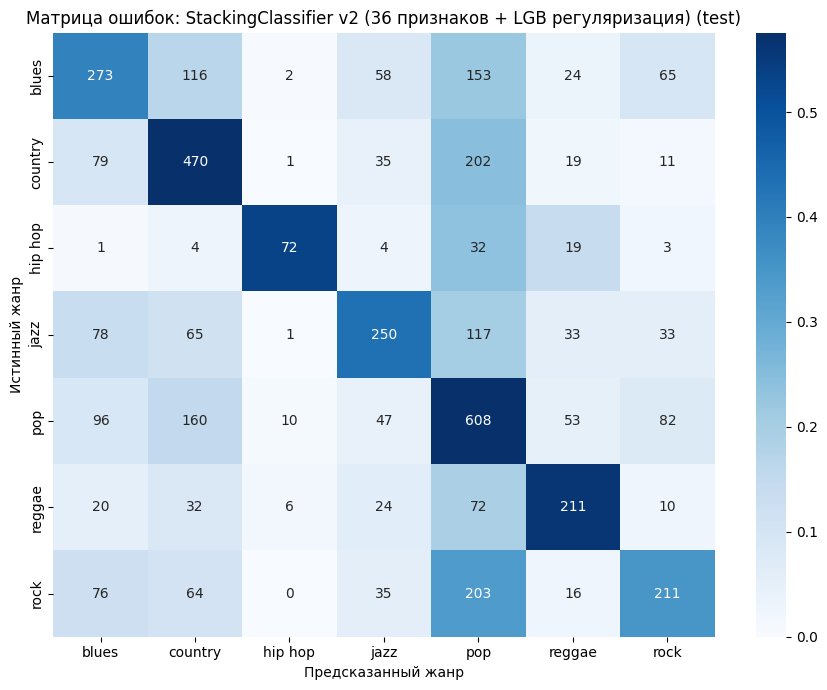

In [26]:
# Матрица ошибок финальной модели
plot_confusion_matrix(
    y_test,
    y_pred_test,
    labels=GENRES,
    title=f"Матрица ошибок: {best_name} (test)",
    save_path=f"{IMAGES_DIR}/confusion_matrix_best.png",
)

**Что видим в матрице ошибок:**

По строкам - реальный жанр, по столбцам - предсказанный. Диагональ - правильные ответы, вне диагонали ошибки. Цвет: чем темнее, тем больше треков попало в эту ячейку.

**Хорошо распознаются:**
- **hip hop** (F1=0.64 на val) - матрица даёт чёткий тёмный квадрат на диагонали, почти без ошибок в другие жанры. Уникальный профиль (современный + нецензурный текст + танцевальность) делает его самым простым классом
- **reggae** (F1=0.57) и **country** (F1=0.54) - достаточно чёткие профили

**Сложные случаи:**
- **blues** (F1=0.40): значительная часть треков предсказывается как country и pop. Blues и country - оба старые акустические жанры с грустными текстами, разница небольшая
- **rock** (F1=0.42): часть треков попадает в pop. Современный рок и поп акустически похожи: оба энергичные, громкие, средняя танцевальность
- **pop** имеет высокий recall (55%) но низкий precision - модель часто перекидывает чужие треки в pop, потому что pop-пространство большое

Эти систематические ошибки - следствие акустического пересечения жанров, которое мы видели на UMAP

In [27]:
# Важность признаков финальной модели (если дерево)
if hasattr(final_model, "feature_importances_"):
    plot_feature_importance(
        final_model.feature_importances_,
        feature_cols,
        title=f"{best_name} — важность признаков (топ-20)",
        save_path=f"{IMAGES_DIR}/best_model_feature_importance.png",
        top_n=20,
    )

## Итоги и выводы

### Сводка всех экспериментов

| № | Модель | Macro F1 (val) | Изменение |
|---|--------|---------------|-----------|
| baseline | LogisticRegression | 0.4161 | — |
| 1 | RandomForest (100 деревьев) | 0.4724 | +5.6% |
| 2 | LightGBM (100 деревьев) | 0.4940 | +7.8% |
| 3 | LinearSVC | 0.4077 | −2.0% |
| 4 | ExtraTrees (100 деревьев) | 0.4699 | +5.2% |
| 5а | RandomForest (GridSearchCV) | 0.4909 | +7.1% |
| 5б | LightGBM (GridSearchCV) | 0.4974 | +7.9% |
| 6 | PCA + RF/LGB | — | вредит качеству |
| 7 | VotingClassifier (RF+LGB+LogReg) | 0.5038 | +10.5% |
| 8 | StackingClassifier v1 (27 признаков) | 0.5106 | +12.0% |
| 9 | LightGBM + 4 взаимодействия (31 признак) | 0.4986 | +8.0% |
| 10а | LightGBM v2 (регуляризация, 27 признаков) | 0.4993 | +8.1% |
| 10б | **StackingClassifier v2 (36 признаков)** | **0.5123** | **+13.1%** |

Все проценты - относительно baseline LogReg (val F1 = 0.4161).

---

### Выбор финальной модели

**Финальная модель: StackingClassifier v2 (36 признаков + LightGBM с регуляризацией)**

Почему именно она:

1. **Лучший Macro F1 на val (0.5123)** - превосходит Stacking v1 (0.5106) и VotingClassifier (0.5038).
2. **Нет переобучения:** val=0.5123 -> test=**0.5076** - незначительный спад (−0.5%), что нормально. Для сравнения, Stacking v1: val=0.5106 -> test=0.5063 (−0.4%). Разрыв между val и test у обоих моделей примерно одинаковый
3. **Стабильность:** LightGBM v2 показал CV F1=0.5021 на 5-fold - без признаков переобучения
4. **Прирост над baseline:** Macro F1 с 0.4228 (LogReg на тесте) до **0.5076** — это **+8.48%** в абсолютном выражении

---

### Почему ансамбль лучше одиночных моделей

Три базовые модели в стеке делают разные ошибки:
- **RandomForest** - высокая дисперсия, ошибается случайно (разные сабсэмплы)
- **LightGBM** - низкая дисперсия, систематически фокусируется на сложных граничных примерах
- **ExtraTrees** - максимальная рандомизация порогов, третий независимый подход

LogisticRegression как мета-learner обучается на out-of-fold предсказаниях всех трёх и учится взвешивать их индивидуально для каждого жанра - в отличие от VotingClassifier, который даёт им фиксированный равный вес

---

### Результаты по классам (StackingClassifier v2, val)

| Жанр | Precision | Recall | F1 | Комментарий |
|------|-----------|--------|-----|-------------|
| **hip hop** | 0.76 | 0.55 | **0.64** | Лучший: уникальный профиль (age, obscene) |
| **reggae** | 0.58 | 0.56 | **0.57** | Чёткие тематические признаки |
| **country** | 0.51 | 0.58 | **0.54** | Хорошо по recall, precision ниже |
| **jazz** | 0.57 | 0.48 | **0.52** | Старая инструментальная - узнаваемый |
| **pop** | 0.44 | 0.57 | **0.50** | Большой класс, хороший recall |
| **rock** | 0.52 | 0.35 | **0.42** | Сложно: пепреходит в pop |
| **blues** | 0.43 | 0.37 | **0.40** | Сложнее всего: похож сильно на country |

---

### Что влияет на ограничения модели

- **UMAP показал:** жанры сильно перекрываются в пространстве 27 признаков. Никакой алгоритм не разделит то, что неразделимо по признакам
- **PCA показал:** все 27 признаков нужны - нет *лишних*, нет корреляций, которые можно было бы сжать
- **Потолок** с текущими признаками - ~0.55–0.60 Macro F1. Преодолеть его можно только новыми типами данных: полные тексты песен - текстовые эмбеддинги, или сырое аудио - MFCC/спектрограммы

## Сохранение финальной модели

Сохраняем модель, scaler и список признаков для последующего использования (деплой, инференс, воспроизводимость).

In [29]:
import joblib

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Определяем итоговый список признаков финальной модели
if feat_flag == "v2":
    saved_feature_cols = feature_cols_v2
elif feat_flag == "ext":
    saved_feature_cols = feature_cols_ext
else:
    saved_feature_cols = feature_cols

# Сохраняем модель, scaler и признаки
joblib.dump(final_model, f"{MODELS_DIR}/best_model.pkl")
joblib.dump(scaler, f"{MODELS_DIR}/scaler.pkl")
joblib.dump(saved_feature_cols, f"{MODELS_DIR}/feature_cols.pkl")

print(f"Сохранено в {MODELS_DIR}/:")
print(f"  best_model.pkl  — {type(final_model).__name__}")
print("  scaler.pkl      — StandardScaler (fit на train)")
print(f"  feature_cols.pkl — {len(saved_feature_cols)} признаков")
print(f"\nТестовый Macro F1: {test_f1:.4f}")
print(
    f"Прирост над LogReg baseline (test): {test_f1 - 0.4228:+.4f} (+{(test_f1 / 0.4228 - 1) * 100:.1f}%)"
)

Сохранено в ../models/:
  best_model.pkl  — StackingClassifier
  scaler.pkl      — StandardScaler (fit на train)
  feature_cols.pkl — 36 признаков

Тестовый Macro F1: 0.5076
Прирост над LogReg baseline (test): +0.0848 (+20.1%)
